In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import timeit
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import LeavePOut

#Letra A

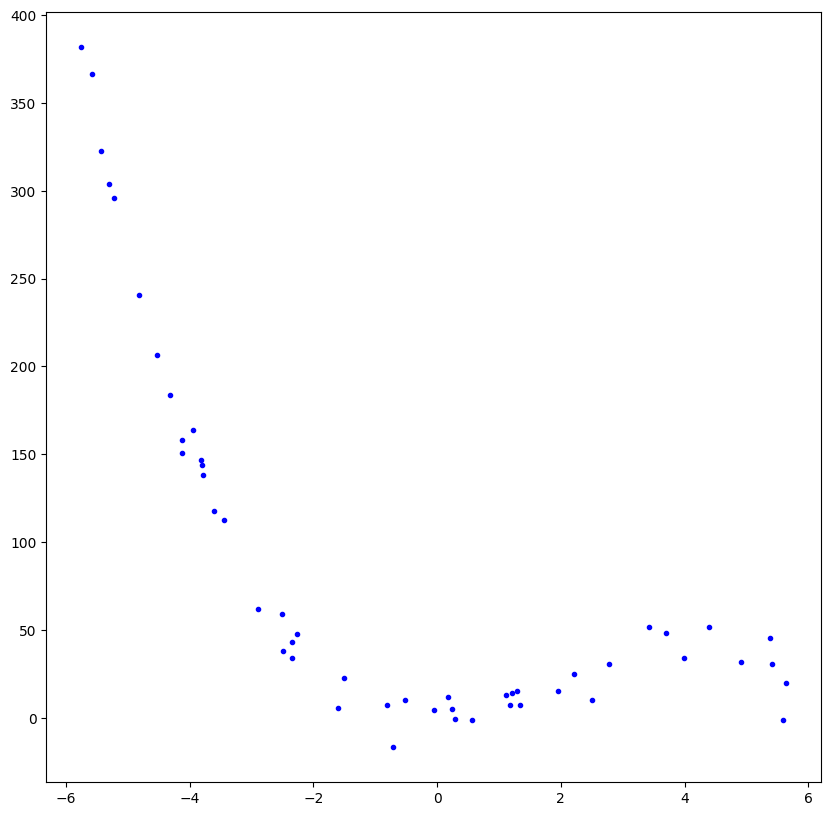

In [2]:
df = pd.read_csv('./polynomialCurve.csv',header=None)
df = df.dropna()
x = df[0].to_numpy()
y = df[1].to_numpy()

x = x.reshape(len(x),1)
yreshape = y.reshape(len(y),1)

fig = plt.figure(figsize=(10,10))
plt.plot(x,y,'b.')

#Validação Cruzada Holdout

In [3]:
# Get timestamp of holdout start.
starttime = timeit.default_timer()

# Split the whole dataset into random training and validation set.
x_train, x_val, y_train, y_val = train_test_split(x, yreshape, test_size=0.3, random_state=42)

# Print size of the datasets.
print('Tamanho do conjunto de treinamento:', len(y_train))
print('Tamanho do conjunto de validação:', len(y_val))

mse_train_vec = []
mse_val_vec = []
# Iterate over the specified degrees.
poly_orders = range(1, 21)
for d in poly_orders:
    # Instantiate a polynomial.
    poly = PolynomialFeatures(degree=d, include_bias=False)
    # Instantiate a scaler.
    scaler = StandardScaler()
    # Instantiate a linear regressor.
    reg = LinearRegression()

    # Create a pipeline of actions.
    poly_reg = Pipeline([
        ("poly", poly),
        ("scaler", scaler),
        ("reg", reg),
    ])

    # Train the model.
    poly_reg.fit(x_train, y_train)

    # Predict with the training dataset.
    y_train_predict = poly_reg.predict(x_train)

    # Predict with the validation dataset.
    y_val_predict = poly_reg.predict(x_val)

    # Calculate and store the MSE for the validation dataset into an array.
    mse_val_vec.append(mean_squared_error(y_val, y_val_predict))

    # Calculate and store the MSE for the training dataset into an array.
    mse_train_vec.append(mean_squared_error(y_train, y_train_predict))

holdout_time = timeit.default_timer() - starttime
print("Tempo de execução do holdout: %1.4f [s]" % (holdout_time))


Tamanho do conjunto de treinamento: 35
Tamanho do conjunto de validação: 15
Tempo de execução do holdout: 0.1338 [s]


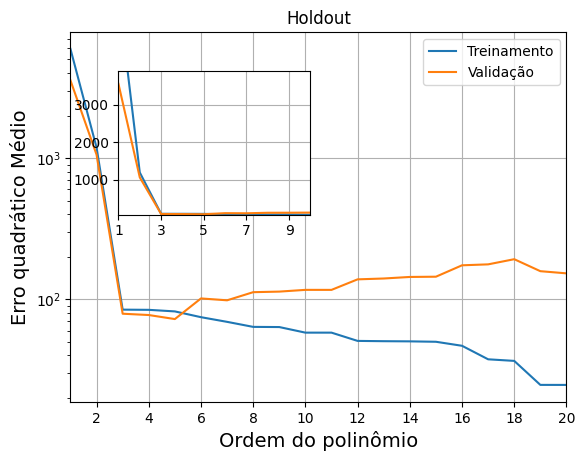

In [4]:
# Plot results.
fig = plt.figure()
plt.plot(poly_orders, mse_train_vec,  label='Treinamento')
plt.plot(poly_orders, mse_val_vec,  label='Validação')
plt.xlabel('Ordem do polinômio', fontsize=14)
plt.ylabel('Erro quadrático Médio', fontsize=14)
plt.xticks(range(0, max(poly_orders)+1, 2))
plt.xlim([1, max(poly_orders)])
plt.yscale('log')
plt.title('Holdout')
plt.legend()
plt.grid()

left, bottom, width, height = [0.2, 0.5, 0.3, 0.3]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.plot(poly_orders, mse_train_vec, label='Treinamento')
ax1.plot(poly_orders, mse_val_vec, label='Validação')
ax1.set_xlim(1, 10)
ax1.set_ylim(min(mse_val_vec[:10]) * 0.9, max(mse_val_vec[:10]) * 1.1)  #corrigido
ax1.set_xticks(range(1, 11, 2))
ax1.grid()


# Save figure.
#plt.savefig("holdout.png", dpi=600)
#Show the plot.
plt.show()

# Validação Cruzada k-fold (k=10 folds)

In [5]:
# Get timestamp of holdout start.
starttime = timeit.default_timer()

# Instantiate the k-Fold object.
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

kfold_mean_vec = []
kfold_std_vec = []
# Iterate over the specified degrees.
poly_orders = range(1, 21)
for d in poly_orders:
    # Instantiate a polynomial.
    poly = PolynomialFeatures(degree=d, include_bias=False)
    # Instantiate a scaler.
    scaler = StandardScaler()
    # Instantiate a linear regressor.
    reg = LinearRegression()

    # Create a pipeline of actions.
    poly_reg = Pipeline([
        ("poly", poly),
        ("scaler", scaler),
        ("reg", reg),
    ])

    # Calculate the cross-validation score with kfold object.
    lin_scores = cross_val_score(poly_reg, x, yreshape, scoring='neg_mean_squared_error', cv=kfold)

    # Convert back to MSE by multiplying it by minus one.
    scores = -lin_scores
    # Mean of the MSE values, i.e., calculate ter MSE for each one of the folds.
    kfold_mean_vec.append(scores.mean())
    # Standard deviation of the MSE values.
    kfold_std_vec.append(scores.std())

kfold_time = timeit.default_timer() - starttime
print("Tempo de execução do k-Fold: %1.4f [s]" % (kfold_time))


Tempo de execução do k-Fold: 1.1529 [s]


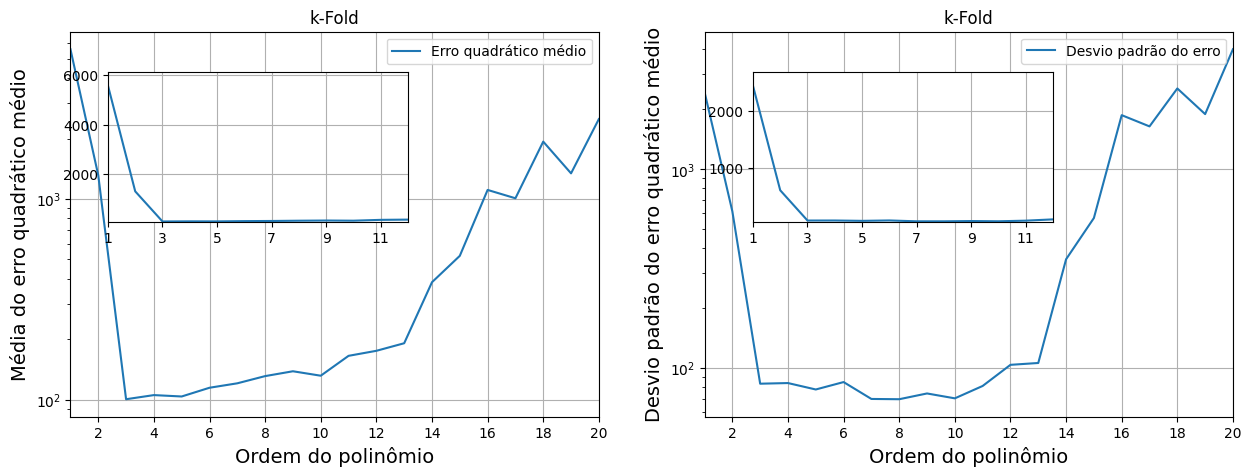

In [6]:
# Plot results.
fig = plt.figure(figsize=(15, 5))

# Gráfico principal - Erro médio
ax = plt.subplot(1, 2, 1)
plt.plot(poly_orders, kfold_mean_vec, label='Erro quadrático médio')
plt.yscale('log')
plt.xlabel('Ordem do polinômio', fontsize=14)
plt.ylabel('Média do erro quadrático médio', fontsize=14)
plt.xticks(range(0, max(poly_orders)+1, 2))
plt.xlim([1, max(poly_orders)])
plt.grid()
plt.title('k-Fold')
plt.legend()

# Inset à esquerda — zoom no erro médio (graus 1 a 12)
left, bottom, width, height = [0.15, 0.5, 0.2, 0.3]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.plot(poly_orders[:12], kfold_mean_vec[:12])
ax1.set_xlim(1, 12)
ax1.set_ylim(min(kfold_mean_vec[:12]) * 0.9, max(kfold_mean_vec[:12]) * 1.1)
ax1.set_xticks(range(1, 13, 2))
ax1.grid()

# Gráfico principal - Desvio padrão
ax = plt.subplot(1, 2, 2)
plt.title('k-Fold')
plt.plot(poly_orders, kfold_std_vec, label='Desvio padrão do erro')
plt.yscale('log')
plt.xlabel('Ordem do polinômio', fontsize=14)
plt.ylabel('Desvio padrão do erro quadrático médio', fontsize=14)
plt.xticks(range(0, max(poly_orders)+1, 2))
plt.xlim([1, max(poly_orders)])
plt.grid()
plt.legend()

# Inset à direita — zoom no desvio padrão
left, bottom, width, height = [0.58, 0.5, 0.2, 0.3]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.plot(poly_orders[:12], kfold_std_vec[:12])
ax2.set_xlim(1, 12)
ax2.set_ylim(min(kfold_std_vec[:12]) * 0.9, max(kfold_std_vec[:12]) * 1.1)
ax2.set_xticks(range(1, 13, 2))
ax2.grid()

plt.show()

# Leave-p-out (p=1)

In [7]:
# Get timestamp of holdout start.
starttime = timeit.default_timer()

# Instantiate the LPOCV object.
lpocv = LeavePOut(p=1)

lpo_mean_vec = []
lpo_std_vec = []
# Iterate over the specified degrees.
poly_orders = range(1, 21)
for d in poly_orders:
    # Instantiate a polynomial.
    poly = PolynomialFeatures(degree=d, include_bias=False)
    # Instantiate a scaler.
    scaler = StandardScaler()
    # Instantiate a linear regressor.
    reg = LinearRegression()

    # Create a pipeline of actions.
    poly_reg = Pipeline([
        ("poly", poly),
        ("scaler", scaler),
        ("reg", reg),
    ])

    # Calculate the cross-validation score with LPO object.
    lin_scores = cross_val_score(poly_reg, x, yreshape, scoring='neg_mean_squared_error', cv=lpocv)

    scores = -lin_scores
    # Mean of the MSE values, i.e., calculate ter MSE for each one of the test sets.
    lpo_mean_vec.append(scores.mean())
    # Standard deviation of the MSE values.
    lpo_std_vec.append(scores.std())

lpo_time = timeit.default_timer() - starttime
print("Tempo de execução do leave-p-out: %1.4f [s] (%1.4f [m])" % (lpo_time, lpo_time/60))


Tempo de execução do leave-p-out: 5.7560 [s] (0.0959 [m])


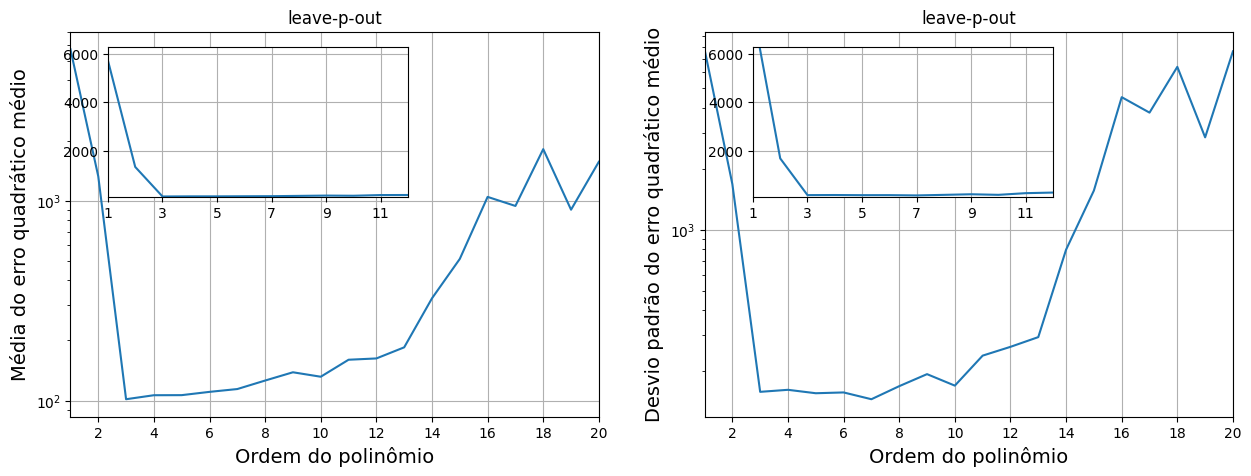

In [8]:
# Plot results.
fig = plt.figure(figsize=(15, 5))
ax = plt.subplot(1, 2, 1)
plt.plot(poly_orders, lpo_mean_vec,  label='Erro quadrático médio')
plt.xlabel('Ordem do polinômio', fontsize=14)
plt.ylabel('Média do erro quadrático médio', fontsize=14)
plt.yscale('log')
plt.xticks(range(0, max(poly_orders)+1, 2))
plt.xlim([1, max(poly_orders)])
plt.grid()
plt.title('leave-p-out')

left, bottom, width, height = [0.15, 0.55, 0.2, 0.3]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.plot(poly_orders, lpo_mean_vec)
ax1.set_xlim(1, 12)
ax1.set_ylim(min(lpo_mean_vec[:12]) * 0.9, max(lpo_mean_vec[:12]) * 1.1)
ax1.set_xticks(range(1,13,2))
ax1.grid()

ax = plt.subplot(1, 2, 2)
plt.plot(poly_orders, lpo_std_vec,  label='Desvio padrão do erro')
plt.xlabel('Ordem do polinômio', fontsize=14)
plt.ylabel('Desvio padrão do erro quadrático médio', fontsize=14)
plt.yscale('log')
plt.xticks(range(0, max(poly_orders)+1, 2))
plt.xlim([1, max(poly_orders)])
plt.grid()
plt.title('leave-p-out')

left, bottom, width, height = [0.58, 0.55, 0.2, 0.3]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.plot(poly_orders, lpo_std_vec)
ax2.set_xlim(1, 12)
ax2.set_ylim(min(lpo_mean_vec[:12]) * 0.9, max(lpo_mean_vec[:12]) * 1.1)
ax2.set_xticks(range(1,13,2))
ax2.grid()

# Save figure
#plt.savefig("leave_p_out.png", dpi=600)
#Show the plot.
plt.show()


#Letra C

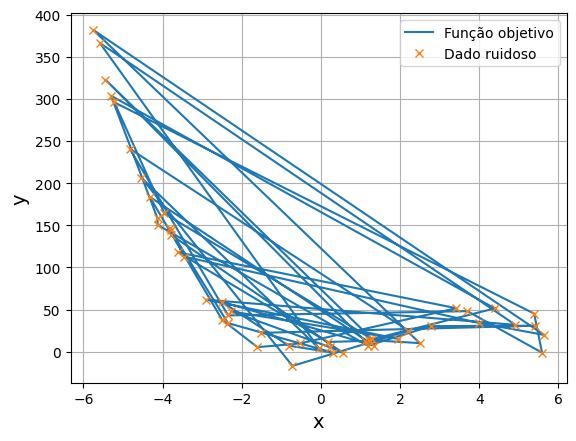

In [11]:
# Example set size.
N = len(x)


# Plot original data versus noisy version.
fig = plt.figure()
plt.plot(x, y, label='Função objetivo')
plt.plot(x, y, 'x', label='Dado ruidoso')
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend()
plt.grid()
# Save figure
#plt.savefig("noisy_function.png", dpi=600)
#Show the plot.
plt.show()

In [12]:
# Polinomial degrees to be tested.
degrees = [1, 2, 3, 50]

# Validation set size.
testSize = [0.1, 0.2, 0.3, 0.4]

# Number of different seeds.
numOfSeeds = 100

mse_training = np.zeros((len(testSize), len(degrees), int(N*(1.0 - 0.1))+1 ))
mse_validation = np.zeros((len(testSize), len(degrees), int(N*(1.0 - 0.1))+1 ))

# Iterate over test sizes.
for t in range(0, len(testSize)):

    # Maximum number of training samples.
    trainSize = int(N*(1.0 - testSize[t]))

    # Iterate over the degrees.
    for i in range(0, len(degrees)):

        # Instantiate a polynomial.
        poly = PolynomialFeatures(degree=degrees[i], include_bias=False)
        # Instantiate a scaler.
        scaler = StandardScaler()
        # Instantiate a linear regressor.
        reg = LinearRegression()

        # Create a pipeline of actions.
        poly_reg = Pipeline([
            ("poly", poly),
            ("scaler", scaler),
            ("reg", reg),
        ])

        # Iterate over the size of the training set.
        for m in range(1, trainSize+1):

            # Use several different seeds.
            for s in range(0, numOfSeeds):

                # Split the whole set into random training and validation set.
                x_train, x_val, y_train, y_val = train_test_split(x, yreshape, test_size=testSize[t], random_state=42)

                # Perform polynomial regression.
                poly_reg.fit(x_train[:m], y_train[:m])

                # Use the trained model for prediction of the training set.
                y_train_predict = poly_reg.predict(x_train[:m])

                # Use the trained model for prediction of the validation set.
                y_val_predict = poly_reg.predict(x_val)

                # Calculate MSE for training set.
                mse_training[t, i, m-1] += mean_squared_error(y_train[:m], y_train_predict)

                # Calculate MSE for validation set.
                mse_validation[t, i, m-1] += mean_squared_error(y_val, y_val_predict)

            mse_training[t, i, m-1] /= numOfSeeds
            mse_validation[t, i, m-1] /= numOfSeeds

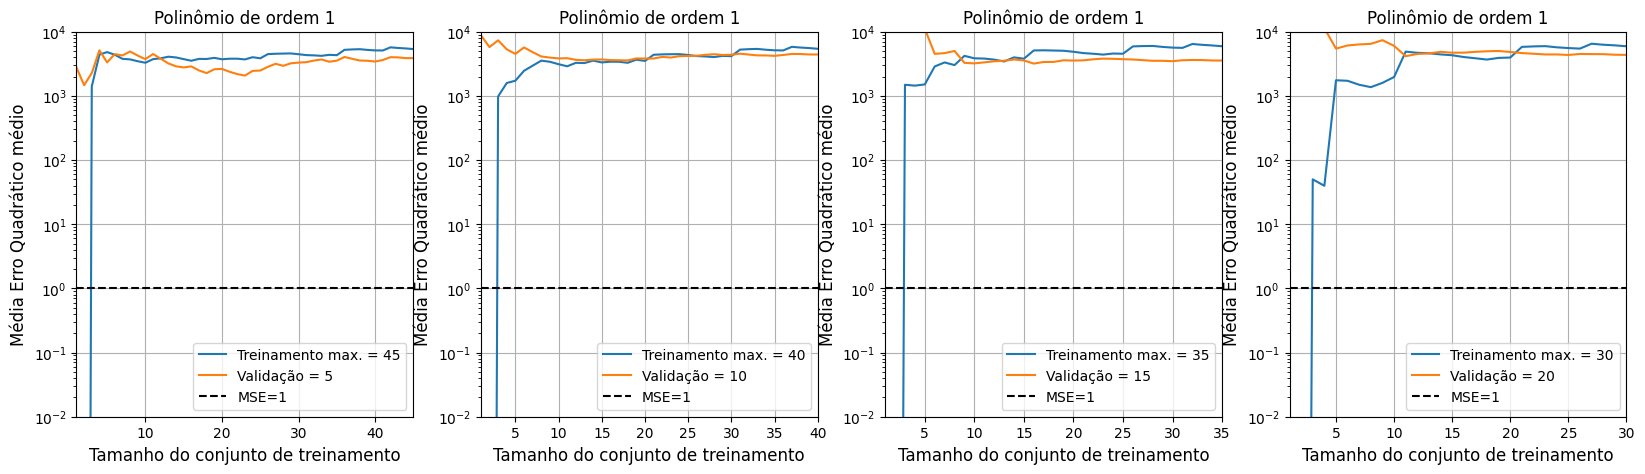

In [13]:
# Polinômio de ordem 1.
i = 0

plt.figure(figsize=(20, 5))
for t in range(0,len(testSize)):

    trainSize = int(N*(1.0 - testSize[t]))

    ax = plt.subplot(1, 4, t + 1)

    ax.plot(range(1, trainSize+1), mse_training[t, i, 0:trainSize], label='Treinamento max. = '+str(trainSize))
    ax.plot(range(1, trainSize+1), mse_validation[t, i, 0:trainSize], label='Validação = '+str(N-trainSize))
    ax.plot(range(1, trainSize+1), np.ones((trainSize,)), 'k--', label='MSE=1')
    ax.set_yscale('log')
    ax.set_xlabel('Tamanho do conjunto de treinamento', fontsize=12)
    ax.set_ylabel('Média Erro Quadrático médio', fontsize=12)
    ax.grid()
    ax.set_ylim([1e-2, 1e4])
    ax.set_xlim([1, trainSize])
    ax.set_title('Polinômio de ordem '+str(degrees[i]))
    ax.legend(loc='best')

# Show the plot.
plt.show()

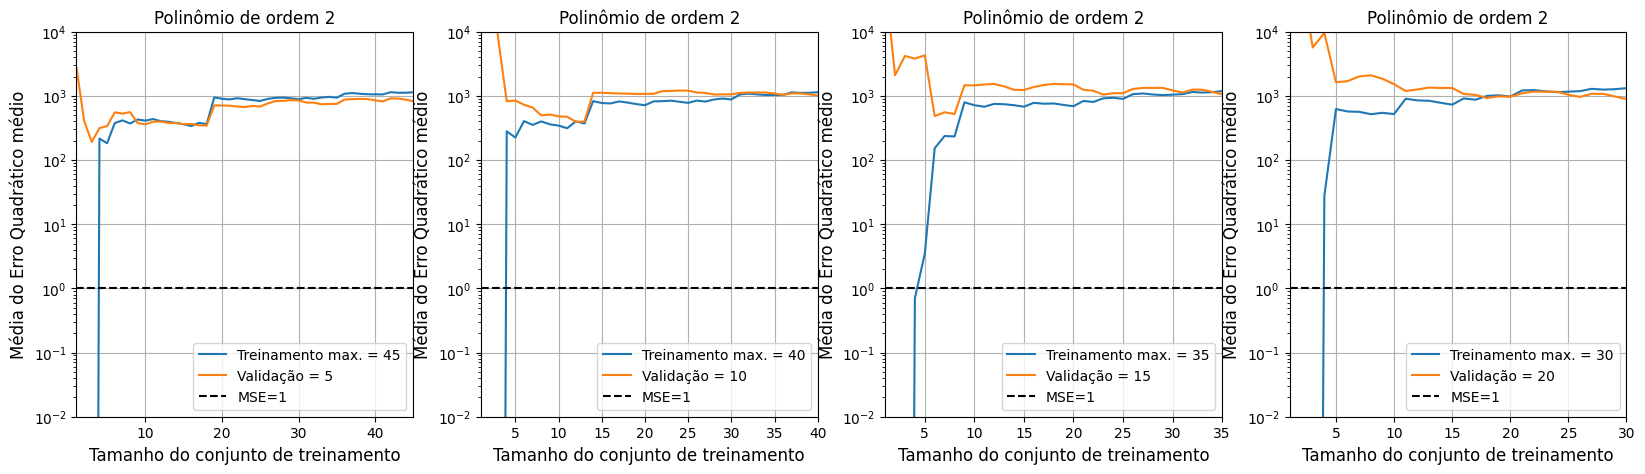

In [14]:
# Polinômio de ordem 2.
i = 1

plt.figure(figsize=(20, 5))
for t in range(0,len(testSize)):

    trainSize = int(N*(1.0 - testSize[t]))

    ax = plt.subplot(1, 4, t + 1)

    ax.plot(range(1, trainSize+1), mse_training[t, i, 0:trainSize], label='Treinamento max. = '+str(trainSize))
    ax.plot(range(1, trainSize+1), mse_validation[t, i, 0:trainSize], label='Validação = '+str(N-trainSize))
    ax.plot(range(1, trainSize+1), np.ones((trainSize,)), 'k--', label='MSE=1')
    ax.set_yscale('log')
    ax.set_xlabel('Tamanho do conjunto de treinamento', fontsize=12)
    ax.set_ylabel('Média do Erro Quadrático médio', fontsize=12)
    ax.grid()
    ax.set_ylim([1e-2, 1e4])
    ax.set_xlim([1, trainSize])
    ax.set_title('Polinômio de ordem '+str(degrees[i]))
    ax.legend(loc='best')

# Show the plot.
plt.show()

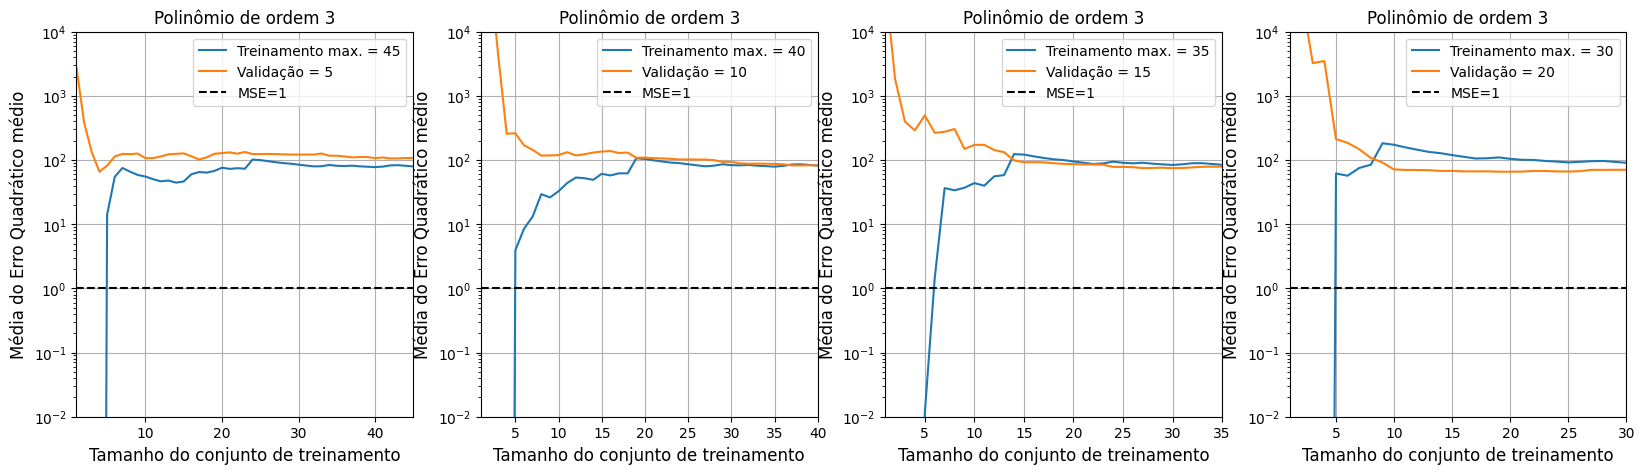

In [15]:
# Polinômio de ordem 3.
i = 2

plt.figure(figsize=(20, 5))
for t in range(0,len(testSize)):

    trainSize = int(N*(1.0 - testSize[t]))

    ax = plt.subplot(1, 4, t + 1)

    ax.plot(range(1, trainSize+1), mse_training[t, i, 0:trainSize], label='Treinamento max. = '+str(trainSize))
    ax.plot(range(1, trainSize+1), mse_validation[t, i, 0:trainSize], label='Validação = '+str(N-trainSize))
    ax.plot(range(1, trainSize+1), np.ones((trainSize,)), 'k--', label='MSE=1')
    ax.set_yscale('log')
    ax.set_xlabel('Tamanho do conjunto de treinamento', fontsize=12)
    ax.set_ylabel('Média do Erro Quadrático médio', fontsize=12)
    ax.grid()
    ax.set_ylim([1e-2, 1e4])
    ax.set_xlim([1, trainSize])
    ax.set_title('Polinômio de ordem '+str(degrees[i]))
    ax.legend(loc='best')

# Show the plot.
plt.show()

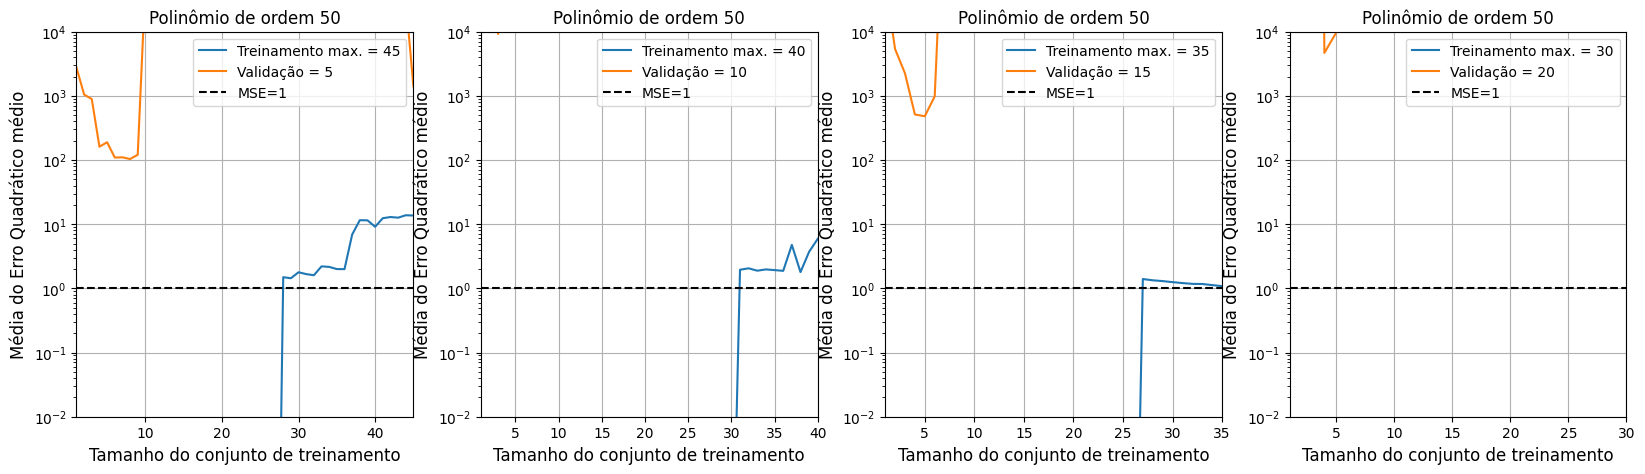

In [16]:
# Polinômio de ordem 50.
i = 3

plt.figure(figsize=(20, 5))
for t in range(0,len(testSize)):

    trainSize = int(N*(1.0 - testSize[t]))

    ax = plt.subplot(1, 4, t + 1)

    ax.plot(range(1, trainSize+1), mse_training[t, i, 0:trainSize], label='Treinamento max. = '+str(trainSize))
    ax.plot(range(1, trainSize+1), mse_validation[t, i, 0:trainSize], label='Validação = '+str(N-trainSize))
    ax.plot(range(1, trainSize+1), np.ones((trainSize,)), 'k--', label='MSE=1')
    ax.set_yscale('log')
    ax.set_xlabel('Tamanho do conjunto de treinamento', fontsize=12)
    ax.set_ylabel('Média do Erro Quadrático médio', fontsize=12)
    ax.grid()
    ax.set_ylim([1e-2, 1e4])
    ax.set_xlim([1, trainSize])
    ax.set_title('Polinômio de ordem '+str(degrees[i]))
    ax.legend(loc='best')

# Show the plot.
plt.show()

#Respostas.
i) O subajuste ocorre quando o modelo é muito simples para pegar a complexidade dos dados. É visto quando o erro no conjunto de treinamento é alto, e o de validação também é alto. No meu entendimento os polinômios de baixa ordem (1 e 2) resultam em subajuste, o modelo não consegue adequar aos dados.

ii) O sobreajuste ocorre quando o modelo é muito complexo e se ajusta demais aos dados de treinamento, até mesmo os ruídos. É visto quando tem um erro muito baixo no conjunto de treinamento, mas um erro grande no conjunto de validação. No gráfico de holdout dá pra ver isso. Poliômio de ordem mais alta (50) são mais propensos a aconter isso.

iii) É necessário encontrar um equilíbrio entre subajuste e sobreajuste, criando um modelo que tenha uma boa generalização. Aqui um bom modelo, é aquele que tenho um baixo erro em treinamento e validação. Visto abaixo no gráfico feito, na minha opinião o melhor grau de polinômi para aproximar os dados do arquivo é o de ordem 3.

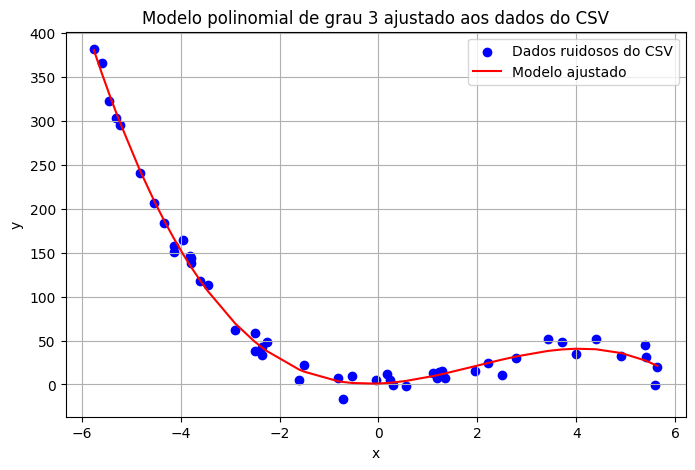

In [22]:
# 2. Definir o modelo polinomial (grau 3, por exemplo)
grau = 3
modelo = Pipeline([
    ('poly', PolynomialFeatures(degree=grau, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

# 3. Treinar o modelo com os dados do CSV
modelo.fit(x, y)

# 4. Prever os valores de y com os x do CSV
y_pred = modelo.predict(x)

# 5. Plotar os pontos ruidosos e a curva do modelo
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label='Dados ruidosos do CSV')
plt.plot(np.sort(x, axis=0), y_pred[np.argsort(x, axis=0)], color='red', label='Modelo ajustado')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Modelo polinomial de grau {grau} ajustado aos dados do CSV')
plt.grid(True)
plt.legend()
plt.show()